# Stripe Collapse Probabilities
This notebook has been created to investigate the fact that for some sites the return periods selected for the MSA do not cause a sufficient number of collapses to facilitate the fitting of a fragility curve. Obviously the initial guess of the failure window was not accurate enough.

Using the results of some previous IDA analyses the resulting fragility curves the expected number of collapses expected for the IML of each stripe can be estimated. Following that the IDA results can also be used to determine a suitable window of IMLs for the MSA be choosing IMLs/RTPs at each site that will cause a suitable number of collapses

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd 

from phd_project.config import config
from phd_project.scripts.WP1_ground_motion_set.hazard import poe_to_mafe

cfg = config.load_config()

In [3]:
HAZ_ROOT = cfg["proc_data"]["site_hazard"]

In [4]:
# Load the hazard data
with open(HAZ_ROOT / "AvgSA_03_disagg_stats_60sites.pickle", "rb") as file:
    disagg_stats_03 = pickle.load(file)

with open(HAZ_ROOT / "AvgSA_03_hazard_curves_60sites.pickle", "rb") as file:
    hcs_03 = pickle.load(file)

# Load the casestudy design data
# Site independent case studies
with open(cfg["proc_data"]["dc2_casestudy_dataset"], "rb") as f:
    reference_designs = pickle.load(f)

reference_designs = reference_designs.set_index("name")
reference_designs = reference_designs.drop(columns="index")
reference_designs["Vb_coeff"] = reference_designs["design_baseshear"] / (reference_designs["seismic_mass"] * 9.81)

# site dependent data
sitespec_design_summary_fp = Path(cfg["models"]["casestudy_designs_site_specific"] / "site_designs_summary.csv")
sitespec_designs = pd.read_csv(sitespec_design_summary_fp)


In [5]:
reference_designs

,n_storeys,roof_height,V_wind_GQWSI_LC1,V_wind_GQWSI_LC2,V_wind_GQWSI_LC3,T1_GQWSI_LC1,T1_GQWSI_LC2,T1_GQWSI_LC3,gravity_frame_elastic_baseshear,gravity_design_equivalent_seismic_baseshear,...,seismic_F6,seismic_F7,seismic_V1,seismic_V2,seismic_V3,seismic_V4,seismic_V5,seismic_V6,seismic_V7,Vb_coeff
name,,,,,,,,,,,,,,,,,,,,,
3s_cbf_dc2_10,3,10500,19855.845357,33093.075595,19855.845357,0.884937,0.864221,0.875094,1.940971e+05,79905.842715,...,NaN,NaN,17069.007996,51207.023987,9.692758e+04,NaN,NaN,NaN,NaN,0.031657
3s_cbf_dc2_20,3,10500,19855.845357,33093.075595,19855.845357,0.767450,0.749553,0.759012,3.858510e+05,79905.842715,...,NaN,NaN,39119.717226,117359.151677,2.221441e+05,NaN,NaN,NaN,NaN,0.072553
3s_cbf_dc2_31,3,10500,19855.845357,33093.075595,19855.845357,0.634683,0.621273,0.629798,7.502664e+05,79905.842715,...,NaN,NaN,91541.379705,274624.139115,5.198243e+05,NaN,NaN,NaN,NaN,0.169777
3s_cbf_dc2_41,3,10500,19855.845357,33093.075595,19855.845357,0.562798,0.551065,0.558700,9.831009e+05,79905.842715,...,NaN,NaN,135192.440416,405577.321247,7.676999e+05,NaN,NaN,NaN,NaN,0.250735
3s_cbf_dc2_51,3,10500,19855.845357,33093.075595,19855.845357,0.537063,0.525928,0.533244,1.589369e+06,79905.842715,...,NaN,NaN,164623.935396,493871.806189,9.348288e+05,NaN,NaN,NaN,NaN,0.305320
3s_cbf_dc2_61,3,10500,19855.845357,33093.075595,19855.845357,0.516356,0.505608,0.512619,1.876711e+06,79905.842715,...,NaN,NaN,192517.767849,577553.303547,1.093226e+06,NaN,NaN,NaN,NaN,0.357053
3s_cbf_dc2_71,3,10500,19855.845357,33093.075595,19855.845357,0.499045,0.488803,0.495654,2.156086e+06,79905.842715,...,NaN,NaN,218973.773887,656921.321660,1.243458e+06,NaN,NaN,NaN,NaN,0.406120
3s_cbf_dc2_102,3,10500,19855.845357,33093.075595,19855.845357,0.456553,0.446897,0.453017,2.971518e+06,79905.842715,...,NaN,NaN,291850.005736,875550.017208,1.657291e+06,NaN,NaN,NaN,NaN,0.541280
3s_cbf_dc2_122,3,10500,19855.845357,33093.075595,19855.845357,0.437225,0.428202,0.434177,3.456972e+06,79905.842715,...,NaN,NaN,331534.014792,994602.044377,1.882640e+06,NaN,NaN,NaN,NaN,0.614880


In [6]:
sitespec_designs.sort_values("Vb_coeff")

,tag,S_alpha_RP,design_in_json,design_out_json,pickle,success,Vb,Wt,Vb_coeff,T,q_design,S_r
22,3s_cbf_dc2_site29,0.134319,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,7.990584e+04,3061800.0,0.026098,0.719978,1.429709,0.026098
34,3s_cbf_dc2_site4,0.137161,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,7.990584e+04,3061800.0,0.026098,0.719978,1.459951,0.026098
58,3s_cbf_dc2_site8,0.143228,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,7.990584e+04,3061800.0,0.026098,0.719978,1.524535,0.026098
11,3s_cbf_dc2_site19,0.181265,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,7.990584e+04,3061800.0,0.026098,0.719978,1.929403,0.026098
20,3s_cbf_dc2_site27,0.192986,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,8.046056e+04,3061800.0,0.026279,0.719978,2.040000,0.026279
19,3s_cbf_dc2_site26,0.193018,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,8.047403e+04,3061800.0,0.026283,0.719978,2.040000,0.026283
0,3s_cbf_dc2_site0,0.209594,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,8.738487e+04,3061800.0,0.028540,0.719978,2.040000,0.028540
18,3s_cbf_dc2_site25,0.215247,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,8.974180e+04,3061800.0,0.029310,0.719978,2.040000,0.029310
23,3s_cbf_dc2_site3,0.229135,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,9.714591e+04,3061800.0,0.031728,0.708017,2.040000,0.031728
45,3s_cbf_dc2_site5,0.242517,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,1.060324e+05,3061800.0,0.034631,0.686561,2.040000,0.034631


## 1. Reference collapse fragilities

The nine site-independent reference designs (all 3-storey) have IDA-derived collapse fragilities in
`mdof_fragility_curves.pickle`. The medians are in **mm/s²** of AvgSA(0-3s), whereas the hazard IMLs
in `disagg_stats_03` are in **g**, so a factor of `g = 9810` is needed to compare them.

Note the fragilities are **not monotonic** in `Vb_coeff`: `3s_cbf_dc2_10` (the weakest design) has a
*higher* collapse median than `3s_cbf_dc2_20`. This is almost certainly because `_10` is wind-governed
- all 3-storey designs share the same wind base shear - so its members are stronger than its seismic
design coefficient implies.

In [7]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from scipy.stats import lognorm

from phd_project.scripts.WP1_ground_motion_set.hazard import poe_to_rtp

G = 9810.0  # mm/s^2, to convert the hazard IMLs (g) into the fragility units
N_RECORDS = 30  # records per stripe, uniform across all 360 (site, poe) ensembles
LO, HI = 3, 27  # collapses out of N_RECORDS over which a binomial-MLE fit is well conditioned

with open(cfg["proc_data"]["sdof_fragility_curves"] / "mdof_fragility_curves.pickle", "rb") as file:
    mdof_fragilities = pickle.load(file)

refs = pd.DataFrame(
    [
        {
            "name": name,
            "Vb_coeff": reference_designs.loc[name, "Vb_coeff"],
            "median": frag.median,
            "dispersion": frag.dispersion,
        }
        for name, frag in mdof_fragilities.items()
    ]
).sort_values("Vb_coeff", ignore_index=True)

# np.interp requires ascending x; the y-values (P[C]) need not be monotonic
assert refs["Vb_coeff"].is_monotonic_increasing

vb_ref = refs["Vb_coeff"].to_numpy()
refs

,name,Vb_coeff,median,dispersion
0,3s_cbf_dc2_10,0.031657,3752.592658,0.188868
1,3s_cbf_dc2_20,0.072553,3210.207261,0.160847
2,3s_cbf_dc2_31,0.169777,4644.606172,0.201725
3,3s_cbf_dc2_41,0.250735,5762.196292,0.225877
4,3s_cbf_dc2_51,0.305320,6452.143188,0.254091
5,3s_cbf_dc2_61,0.357053,7121.581405,0.251887
6,3s_cbf_dc2_71,0.406120,8099.209302,0.237370
7,3s_cbf_dc2_102,0.541280,9315.301570,0.240261
8,3s_cbf_dc2_122,0.614880,10396.599263,0.246119


## 2. Build the stripe table

One row per (site, stripe). The site id has to be parsed out of the design `tag` because
`sitespec_designs` is ordered lexicographically (`site0, site1, site10, ...`), so row *i* is not site *i*.

In [14]:
sitespec_designs["site_id"] = sitespec_designs["tag"].str.extract(r"site(\d+)$").astype(int)

stripes = disagg_stats_03.merge(
    sitespec_designs[["site_id", "tag", "Vb_coeff"]], on="site_id", how="left"
)
assert stripes["Vb_coeff"].notna().all()

# label the 6 hazard levels with their nominal return periods
NOMINAL_RTPS = [200, 475, 1000, 2475, 5000, 10000]
stripes["rtp"] = poe_to_rtp(stripes["poe"])
stripes["rtp_label"] = stripes["poe"].map(
    dict(zip(sorted(stripes["poe"].unique(), reverse=True), NOMINAL_RTPS))
)
assert np.allclose(stripes["rtp"], stripes["rtp_label"], rtol=0.01)

stripes

,site_id,lat,lon,seismicity,region,imt,poe,imtl,Craton [%],Non-Subduction Deep [%],Shallow Default [%],Subduction Inslab [%],Subduction Interface [%],Volcanic [%],Mag_mean,Dist_mean,tag,Vb_coeff,rtp,rtp_label
0,30,37.7,-1.71787,high,0,AvgSA,0.004988,0.034599,0.0,0.0,99.06,0.94,0.0,0.0,6.16,19.47,3s_cbf_dc2_site30,0.157304,199.980738,200
1,30,37.7,-1.71787,high,0,AvgSA,0.002103,0.082468,0.0,0.0,99.73,0.27,0.0,0.0,6.23,8.73,3s_cbf_dc2_site30,0.157304,475.010999,475
2,30,37.7,-1.71787,high,0,AvgSA,0.001000,0.154695,0.0,0.0,99.92,0.08,0.0,0.0,6.29,6.09,3s_cbf_dc2_site30,0.157304,999.499917,1000
3,30,37.7,-1.71787,high,0,AvgSA,0.000404,0.259683,0.0,0.0,99.98,0.02,0.0,0.0,6.34,5.32,3s_cbf_dc2_site30,0.157304,2474.747491,2475
4,30,37.7,-1.71787,high,0,AvgSA,0.000201,0.351373,0.0,0.0,99.99,0.01,0.0,0.0,6.37,5.13,3s_cbf_dc2_site30,0.157304,4974.624361,5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,29,40.9,-8.51787,lowmod,5,AvgSA,0.002103,0.018199,0.0,0.0,100.00,0.00,0.0,0.0,6.34,66.24,3s_cbf_dc2_site29,0.026098,475.010999,475
356,29,40.9,-8.51787,lowmod,5,AvgSA,0.001000,0.028394,0.0,0.0,100.00,0.00,0.0,0.0,6.47,52.09,3s_cbf_dc2_site29,0.026098,999.499917,1000
357,29,40.9,-8.51787,lowmod,5,AvgSA,0.000404,0.047622,0.0,0.0,100.00,0.00,0.0,0.0,6.58,35.99,3s_cbf_dc2_site29,0.026098,2474.747491,2475
358,29,40.9,-8.51787,lowmod,5,AvgSA,0.000201,0.070290,0.0,0.0,100.00,0.00,0.0,0.0,6.66,25.22,3s_cbf_dc2_site29,0.026098,4974.624361,5000


## 3. Expected collapses per stripe

For each stripe IML, evaluate P[C] under **every** reference fragility, then interpolate those
probabilities against the site's `Vb_coeff`. `np.interp` does the bracketing for us (it picks the one or
two designs either side) and it **clamps** outside the reference range, which is what we want at the low
end: 8 sites are weaker than `3s_cbf_dc2_10` and are given its fragility unchanged. Extrapolating instead
would be wrong here, because the `_10`/`_20` slope is negative and would make the weakest sites look
*stronger* than `_10`.

The expected number of collapses is then simply `P[C] x 30`.

In [9]:
# P[C] at every stripe IML under every reference fragility -> (n_stripes, n_refs)
pc_ref = lognorm.cdf(
    stripes["imtl"].to_numpy(dtype=float)[:, None] * G,
    refs["dispersion"].to_numpy()[None, :],
    scale=refs["median"].to_numpy()[None, :],
)

stripes["p_collapse"] = [
    np.interp(vb, vb_ref, row) for vb, row in zip(stripes["Vb_coeff"], pc_ref)
]
stripes["expected_collapses"] = stripes["p_collapse"] * N_RECORDS

assert stripes["p_collapse"].between(0, 1).all()

# sites below the weakest reference must land exactly on the _10 fragility
below = (stripes["Vb_coeff"] < vb_ref[0]).to_numpy()
assert np.allclose(stripes.loc[below, "p_collapse"], pc_ref[below, 0])
print("clamped to 3s_cbf_dc2_10:", sorted(stripes.loc[below, "site_id"].unique()))

# within a site, collapses must grow with return period
monotonic = (
    stripes.sort_values("rtp").groupby("site_id")["expected_collapses"].apply(lambda s: s.is_monotonic_increasing)
)
assert monotonic.all(), monotonic[~monotonic]

clamped to 3s_cbf_dc2_10: [np.int64(0), np.int64(4), np.int64(8), np.int64(19), np.int64(25), np.int64(26), np.int64(27), np.int64(29)]


In [10]:
# Cross-check the vectorised result the long way, on a site bracketed by two reference designs
mid = stripes[(stripes.Vb_coeff > 0.15) & (stripes.Vb_coeff < 0.19)].iloc[0]
i = int(np.searchsorted(vb_ref, mid.Vb_coeff))
lo, hi = refs.iloc[i - 1], refs.iloc[i]
p_lo = lognorm.cdf(mid.imtl * G, lo["dispersion"], scale=lo["median"])
p_hi = lognorm.cdf(mid.imtl * G, hi["dispersion"], scale=hi["median"])
p_manual = np.interp(mid.Vb_coeff, [lo["Vb_coeff"], hi["Vb_coeff"]], [p_lo, p_hi])

print(f"site {int(mid.site_id)}, Vb_coeff={mid.Vb_coeff:.4f}, bracketed by {lo['name']} / {hi['name']}")
print(f"  vectorised = {mid.p_collapse:.6e}")
print(f"  long-way   = {p_manual:.6e}")
assert np.isclose(mid.p_collapse, p_manual)

site 30, Vb_coeff=0.1573, bracketed by 3s_cbf_dc2_20 / 3s_cbf_dc2_31
  vectorised = 7.962716e-39
  long-way   = 7.962739e-39


## 4. Expected collapses vs RTP and IML

Sites are split 0-29 / 30-59, which coincides exactly with the `lowmod` / `high` seismicity grouping.
Lines are coloured by `Vb_coeff` (design strength) so the ordering is readable through 30 overlapping
curves. The shaded band is the **usable fitting window** - roughly 3 to 27 collapses of 30 - over which
a binomial-MLE fragility fit is well conditioned.

The y-axis is logarithmic: on a linear 0-30 axis nearly every curve would lie flat on zero. Values below
0.01 collapses are clipped to the axis floor.

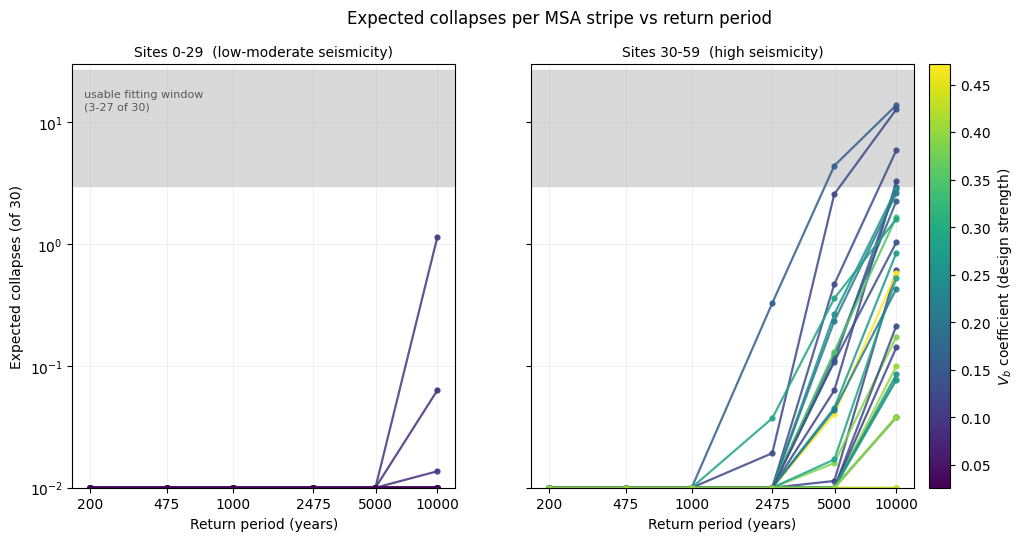

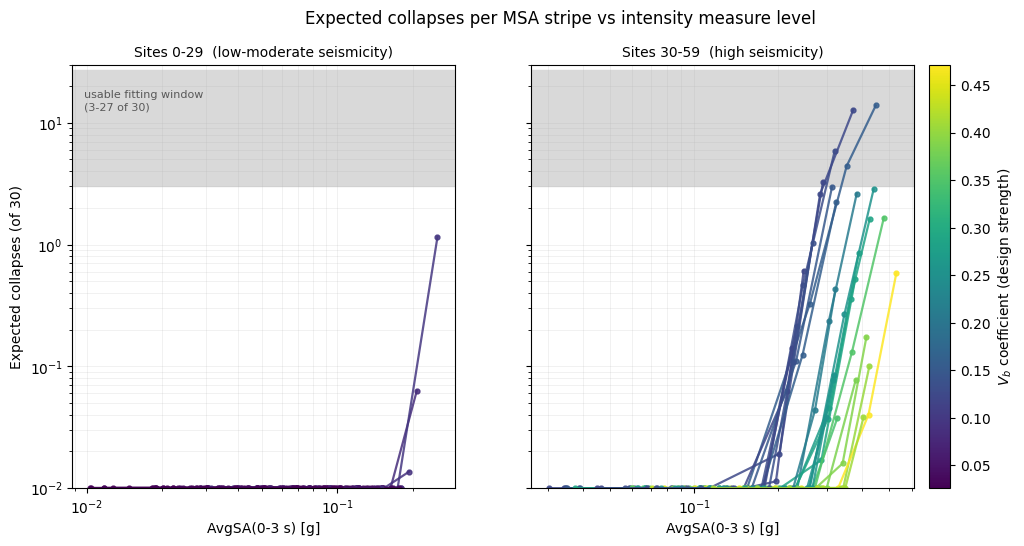

In [11]:
CMAP = plt.get_cmap("viridis")  # sequential: Vb_coeff is a magnitude
NORM = Normalize(vmin=stripes["Vb_coeff"].min(), vmax=stripes["Vb_coeff"].max())
FLOOR = 1e-2  # axis floor for the log y-scale
GROUPS = [
    (range(0, 30), "Sites 0-29  (low-moderate seismicity)"),
    (range(30, 60), "Sites 30-59  (high seismicity)"),
]


def plot_expected_collapses(x_col, x_label, title, x_ticks=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
    for ax, (site_range, panel_title) in zip(axes, GROUPS):
        ax.axhspan(LO, HI, color="0.85", zorder=0)
        for site_id in site_range:
            site = stripes[stripes.site_id == site_id].sort_values("rtp")
            ax.plot(
                site[x_col],
                site["expected_collapses"].clip(lower=FLOOR),
                color=CMAP(NORM(site["Vb_coeff"].iloc[0])),
                lw=1.6, marker="o", ms=3.5, alpha=0.85,
            )
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_ylim(FLOOR, N_RECORDS)
        ax.set_xlabel(x_label)
        ax.set_title(panel_title, fontsize=10)
        ax.grid(alpha=0.25, which="both", lw=0.5)
        if x_ticks is not None:
            ax.set_xticks(x_ticks)
            ax.set_xticklabels([str(t) for t in x_ticks])
            ax.minorticks_off()
    axes[0].set_ylabel(f"Expected collapses (of {N_RECORDS})")
    axes[0].text(
        0.03, 0.94, f"usable fitting window\n({LO}-{HI} of {N_RECORDS})",
        transform=axes[0].transAxes, fontsize=8, color="0.35", va="top",
    )
    cbar = fig.colorbar(ScalarMappable(norm=NORM, cmap=CMAP), ax=axes, pad=0.015)
    cbar.set_label("$V_b$ coefficient (design strength)")
    fig.suptitle(title, fontsize=12)
    return fig


plot_expected_collapses(
    "rtp", "Return period (years)",
    "Expected collapses per MSA stripe vs return period",
    x_ticks=NOMINAL_RTPS,
)
plot_expected_collapses(
    "imtl", "AvgSA(0-3 s) [g]",
    "Expected collapses per MSA stripe vs intensity measure level",
)
plt.show()

## 5. Where the stripes sit on the collapse curve

Applying the same interpolation over a fine IML grid gives each site an interpolated collapse curve. Plotting
the 6 stripe IMLs on top of it shows directly how far short of collapse the current MSA return periods fall,
and gives the IML window we would actually need to target.

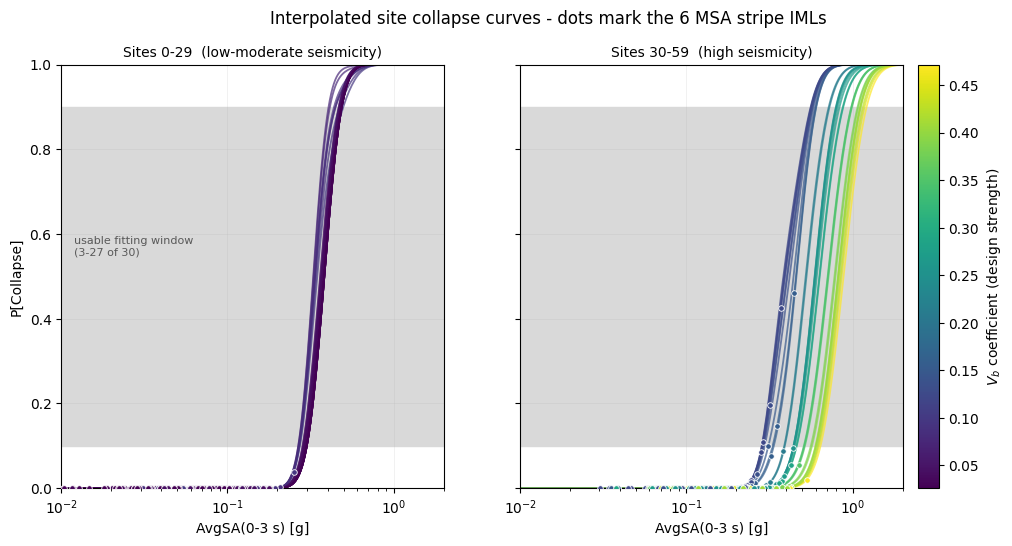

In [12]:
IML_GRID = np.logspace(np.log10(0.01), np.log10(3.0), 300)  # g
PC_GRID_REF = lognorm.cdf(
    IML_GRID[:, None] * G,
    refs["dispersion"].to_numpy()[None, :],
    scale=refs["median"].to_numpy()[None, :],
)  # (n_grid, n_refs)


def site_pc_curve(vb_coeff):
    """P[C] over IML_GRID for a site of the given strength, same interpolation as the stripes."""
    return np.array([np.interp(vb_coeff, vb_ref, row) for row in PC_GRID_REF])


def iml_at_p(vb_coeff, p):
    """The IML (g) at which a site's interpolated collapse curve reaches probability p."""
    return float(np.interp(p, site_pc_curve(vb_coeff), IML_GRID))


# the grid-based curve must reproduce the stripe probabilities computed in section 3
check = stripes.iloc[0]
assert abs(np.interp(check.imtl, IML_GRID, site_pc_curve(check.Vb_coeff)) - check.p_collapse) < 1e-3

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True, sharex=True)
site_vb = sitespec_designs.set_index("site_id")["Vb_coeff"].sort_index()

for ax, (site_range, panel_title) in zip(axes, GROUPS):
    ax.axhspan(LO / N_RECORDS, HI / N_RECORDS, color="0.85", zorder=0)
    for site_id in site_range:
        colour = CMAP(NORM(site_vb[site_id]))
        ax.plot(IML_GRID, site_pc_curve(site_vb[site_id]), color=colour, lw=1.3, alpha=0.7)
        site = stripes[stripes.site_id == site_id]
        ax.plot(
            site["imtl"], site["p_collapse"], ls="none", marker="o", ms=4,
            mfc=colour, mec="white", mew=0.6, zorder=3,
        )
    ax.set_xscale("log")
    ax.set_xlim(0.01, 2.0)
    ax.set_ylim(0, 1)
    ax.set_xlabel("AvgSA(0-3 s) [g]")
    ax.set_title(panel_title, fontsize=10)
    ax.grid(alpha=0.25, lw=0.5)

axes[0].set_ylabel("P[Collapse]")
axes[0].text(0.012, 0.55, f"usable fitting window\n({LO}-{HI} of {N_RECORDS})", fontsize=8, color="0.35")
cbar = fig.colorbar(ScalarMappable(norm=NORM, cmap=CMAP), ax=axes, pad=0.015)
cbar.set_label("$V_b$ coefficient (design strength)")
fig.suptitle("Interpolated site collapse curves - dots mark the 6 MSA stripe IMLs", fontsize=12)
plt.show()

## 6. Summary

Expected collapses at each return period, per site, with a flag for sites where **no** stripe lands in the
usable fitting window.

In [13]:
wide = stripes.pivot_table(index="site_id", columns="rtp_label", values="expected_collapses")

summary = sitespec_designs.set_index("site_id")[["Vb_coeff"]].join(wide)
summary["n_usable"] = wide.apply(lambda row: row.between(LO, HI).sum(), axis=1)
summary["no_usable_stripe"] = summary["n_usable"] == 0

# the IML window we would need to target instead, and how far short the 10000-yr stripe falls
summary["iml_p10"] = [iml_at_p(vb, LO / N_RECORDS) for vb in summary["Vb_coeff"]]
summary["iml_p50"] = [iml_at_p(vb, 0.5) for vb in summary["Vb_coeff"]]
summary["iml_p90"] = [iml_at_p(vb, HI / N_RECORDS) for vb in summary["Vb_coeff"]]
summary["iml_10000yr"] = stripes[stripes.rtp_label == 10000].set_index("site_id")["imtl"]
summary["shortfall_x"] = summary["iml_p50"] / summary["iml_10000yr"]

print(f"sites with no usable stripe: {summary['no_usable_stripe'].sum()} of {len(summary)}")
print(
    "shortfall factor (median capacity / 10000-yr IML): "
    f"min={summary.shortfall_x.min():.2f}  median={summary.shortfall_x.median():.2f}  max={summary.shortfall_x.max():.2f}"
)

summary.sort_values("Vb_coeff").round(3)

sites with no usable stripe: 56 of 60
shortfall factor (median capacity / 10000-yr IML): min=1.02  median=2.09  max=5.64


,Vb_coeff,200,475,1000,2475,5000,10000,n_usable,no_usable_stripe,iml_p10,iml_p50,iml_p90,iml_10000yr,shortfall_x
site_id,,,,,,,,,,,,,,
29,0.026,0.0,0.0,0.000,0.000,0.000,0.000,0,True,0.300,0.383,0.487,0.103,3.719
4,0.026,0.0,0.0,0.000,0.000,0.000,0.000,0,True,0.300,0.383,0.487,0.085,4.515
8,0.026,0.0,0.0,0.000,0.000,0.000,0.000,0,True,0.300,0.383,0.487,0.068,5.640
19,0.026,0.0,0.0,0.000,0.000,0.000,0.000,0,True,0.300,0.383,0.487,0.111,3.456
27,0.026,0.0,0.0,0.000,0.000,0.000,0.000,0,True,0.300,0.383,0.487,0.096,3.993
26,0.026,0.0,0.0,0.000,0.000,0.000,0.000,0,True,0.300,0.383,0.487,0.089,4.303
0,0.029,0.0,0.0,0.000,0.000,0.000,0.000,0,True,0.300,0.383,0.487,0.108,3.552
25,0.029,0.0,0.0,0.000,0.000,0.000,0.000,0,True,0.300,0.383,0.487,0.099,3.872
3,0.032,0.0,0.0,0.000,0.000,0.000,0.000,0,True,0.300,0.382,0.487,0.087,4.398


## 7. Findings

The problem is more severe than "a few sites are mis-targeted": **56 of the 60 sites have no stripe at all in
the usable fitting window**, and the four that do only get there at the 10000-year stripe.

The cause is visible in section 5. The interpolated collapse medians span roughly 0.33-1.06 g of AvgSA(0-3s),
while the largest hazard IML anywhere in the set - the 10000-year level at the strongest site - is only 0.53 g.
Every site's six stripes therefore land on the toe of its own collapse curve. The median site would need an IML
about **2.1x** its 10000-year value to reach 50% collapse (worst case 5.6x).

Two consequences for the MSA:

1. **The failure window cannot be reached by choosing different return periods.** Even the 10000-year hazard
   level is well below collapse for almost every site, and for the low-moderate sites the hazard curve has
   effectively zero POE long before the collapse IMLs are reached - so no finite return period exists there.
   The stripes will have to be defined by scaling to target IMLs directly rather than to hazard levels.
2. `iml_p10` / `iml_p50` / `iml_p90` in the summary table give the per-site IML window to target, derived from
   the same interpolation, and are the natural input to that reselection.

Worth sanity-checking before acting on this: that the site-specific designs really are as strong relative to
their hazard as `Vb_coeff` implies, and that AvgSA(0-3s) is the intended IM for both the fragilities and the
stripe selection. The whole result rests on comparing those two on the same scale.

### Sanity Check

I have performed a sanity check on the AvgSA values to try and find out if there is an error - or the buildings as designed just have a large capacity relative to the seismic hazard level of the sites that they are designed for.

1. I have checked the approximate AvgSA[0,3] calculated from the downloaded ESHM20 2475yr RTP hazard maps against the 2475 yr AvgSA values obtained directly from the reduced hazard model that I have run myself in OpenQuake. A visual comparison seems to indicate that the values of AvgSA from both sources are in the ballpark of each other. There doesn't seem to to be any error larger enough to acount for the 100-500% factor needed to cause a sufficient number of collapses. Based on this I think I can rule out an underestimation of the hazard. Maybe I should do a hazard run for a site at 2475yr for a couple of sites at a few SA(T1) periods to see how much the results differ from my model compared to the original ESHM20 model. --> I haven't done this yet and it would be a good safety check.

2. The second check on AvgSA[0,3] is making sure that the capacity side is correctly represented. The fragility curves of the reference structures were determined from IDA on SA(T1) and then converted to AvgSA[0,3] based on the record scaling factors that cause collapse. A separate notebook (C:\Users\clemettn\Documents\phd\notebooks\03_WP1_ground_motion_set\checks_and_tests\avgSA_conversion.ipynb) has been created to manually check the AvgSA[0,3] conversion. Comparing these values with the values from the fragilty curve conversions (C:\Users\clemettn\Documents\phd\notebooks\03_WP1_ground_motion_set\wp1pt4pt1e_parameterised_sdof_model_for_ida.ipynb, §2.7.1), the values are identical and it appears that the IM conversion of the fragility curves is valid. To double check we can rerun some of the IDAs but this time using the AvgSA[0,3] as the IM.